In [1]:
import math
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

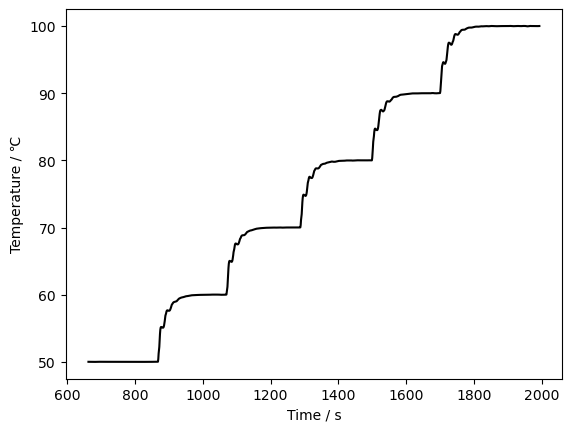

In [4]:
# 读取Excel文件
df1 = pd.read_excel('黑面1.xlsx')

# 获取时间列
times1 = df1['Time']

# 转换为时间戳
timestamps1 = [datetime.strptime(str(time).split('.')[0], "%Y-%m-%d %H:%M:%S") for time in times1]

# 计算每个时间戳对应的秒数
seconds1 = [(timestamp - timestamps1[0]).total_seconds() for timestamp in timestamps1]

# 计算要保留的数据范围
num_points1 = len(seconds1)
start_index1 = num_points1 // 3  # 开始位置为数据长度的1/3处
end_index1 = num_points1  # 结束位置为数据末尾

# 绘制折线图
plt.plot(seconds1[start_index1:end_index1], df1['Untitled'][start_index1:end_index1], color='k')  # 将 'Column2' 替换为实际的第二列数据名称
plt.xlabel('Time / s')
plt.ylabel('Temperature / ℃')
plt.show()

In [4]:
plt.plot??

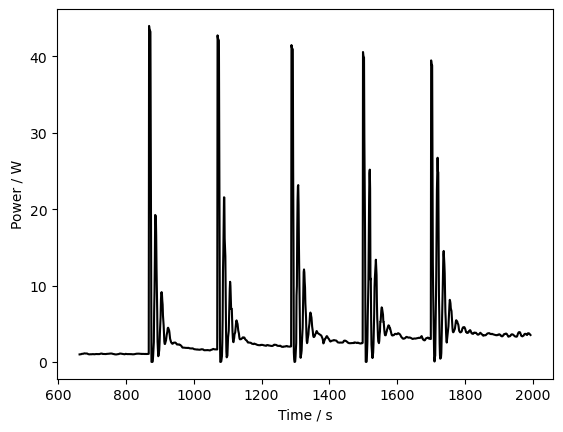

In [5]:
# 读取Excel文件
df2 = pd.read_excel('黑面1.xlsx')

# 获取时间列
times2 = df2['Time']

# 转换为时间戳
timestamps2 = [datetime.strptime(str(time).split('.')[0], "%Y-%m-%d %H:%M:%S") for time in times2]

# 计算每个时间戳对应的秒数
seconds2 = [(timestamp - timestamps2[0]).total_seconds() for timestamp in timestamps2]

# 计算要保留的数据范围
num_points2 = len(seconds2)
start_index2 = num_points2 // 3  # 开始位置为数据长度的1/3处
end_index2 = num_points2  # 结束位置为数据末尾

# 绘制折线图
plt.plot(seconds2[start_index2:end_index2], df2['Untitled 1'][start_index2:end_index2], color='k')  # 将 'Column2' 替换为实际的第二列数据名称
plt.xlabel('Time / s')
plt.ylabel('Power / W')
plt.show()

拟合参数: [ 1.90961957e-08  9.02840063e+00 -1.27858315e+02]
相关系数: 0.9998327702164963


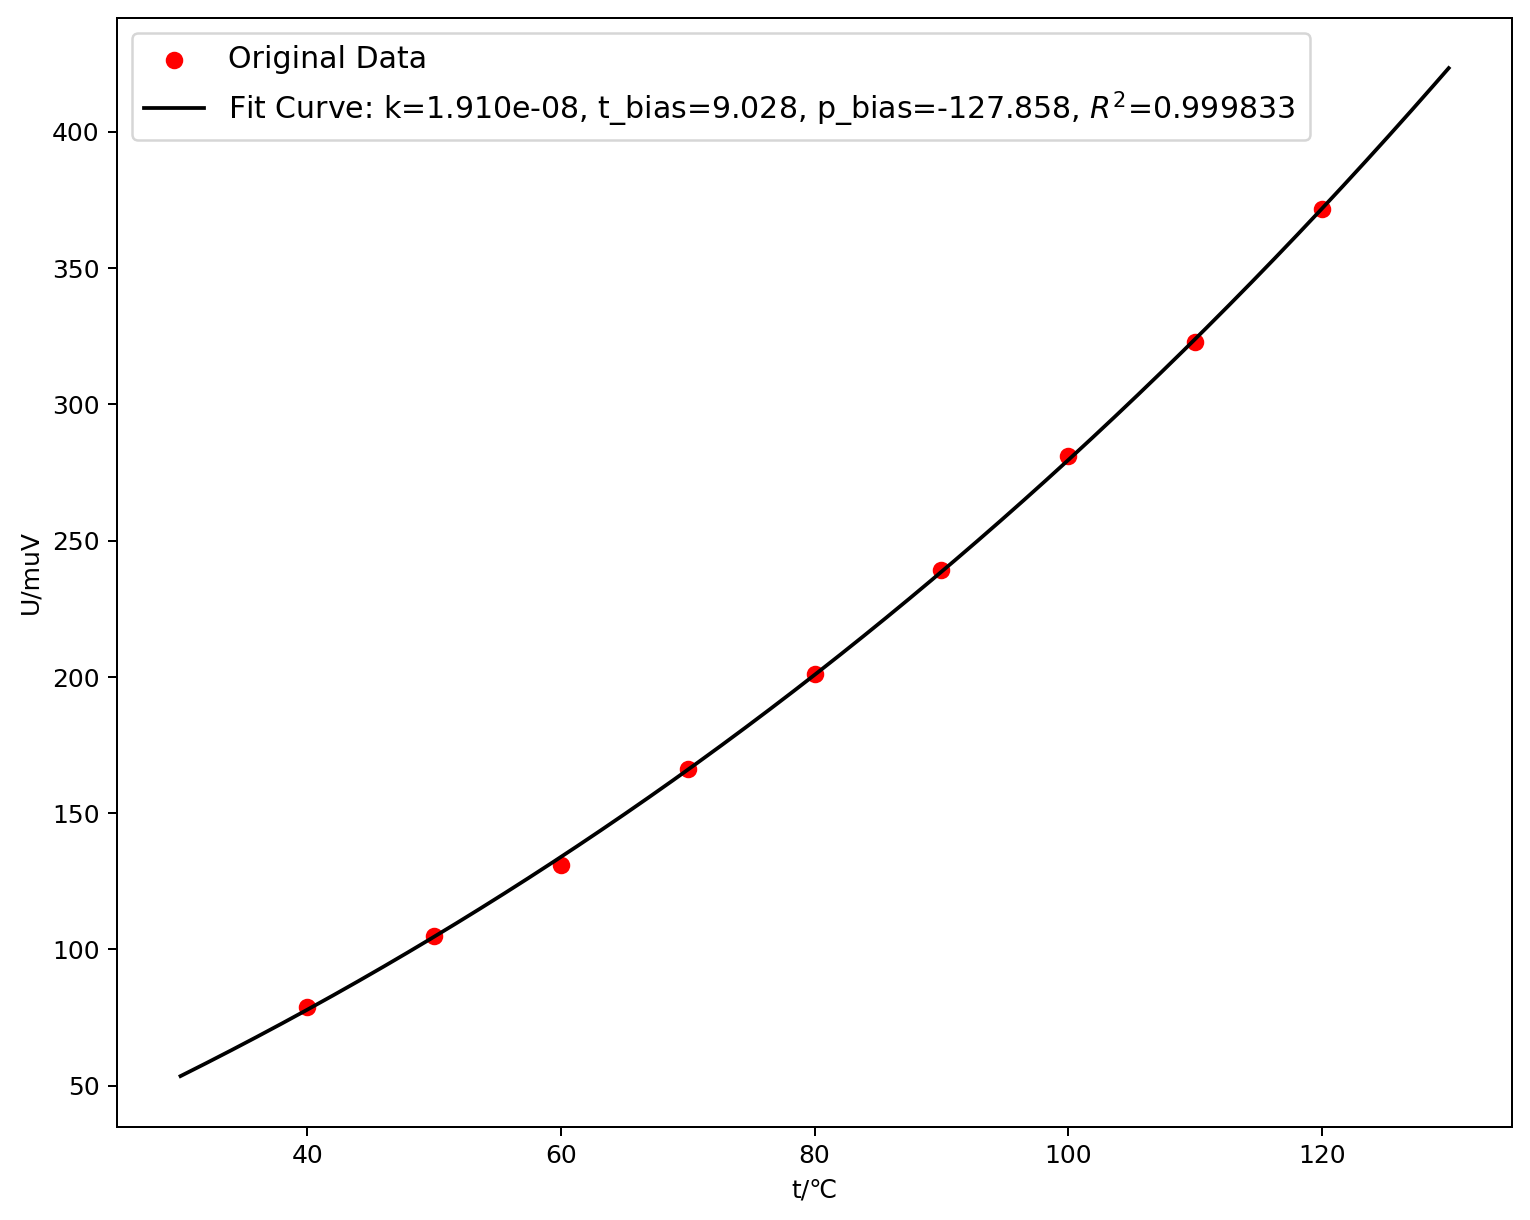

In [20]:
# 读取Excel文件中的数据
df3 = pd.read_excel('data.xlsx', sheet_name='T')

# 提取需要拟合的数据列
# 将x_data和y_data转换为numpy数组
x_data3 = np.array(df3['表面温度'])
y_data3 = np.array(df3['辐射传感器电压/mV'])


# 定义要拟合的函数模型
def func3(t, k, t_bias, p_bias):
    return k * (t + 273.15 + t_bias)**4 + p_bias

# 使用curve_fit进行拟合
popt3, pcov3 = curve_fit(func3, x_data3, y_data3)

# 计算相关系数
residuals3 = y_data3 - func3(x_data3, *popt3)
ss_res3 = np.sum(residuals3**2)
ss_tot3 = np.sum((y_data3 - np.mean(y_data3))**2)
r_squared3 = 1 - (ss_res3 / ss_tot3)

# 输出拟合参数
print("拟合参数:", popt3)
print("相关系数:", r_squared3)
x_plot3 = np.linspace(30, 130, num=1000)

# 绘制拟合结果
plt.figure(figsize=(10, 8), dpi=180) # 图像大小，清晰度
plt.scatter(x_data3, y_data3, label='Original Data', color='r')

plt.plot(x_plot3, func3(x_plot3, *popt3), 'k-', label='Fit Curve: k=%5.3e, t_bias=%5.3f, p_bias=%5.3f, $R^2$=%.6f ' % (*popt3, r_squared3))

plt.xlabel('t/℃')
plt.ylabel('U/muV')
plt.legend(fontsize=12) # 标签大小
plt.show()

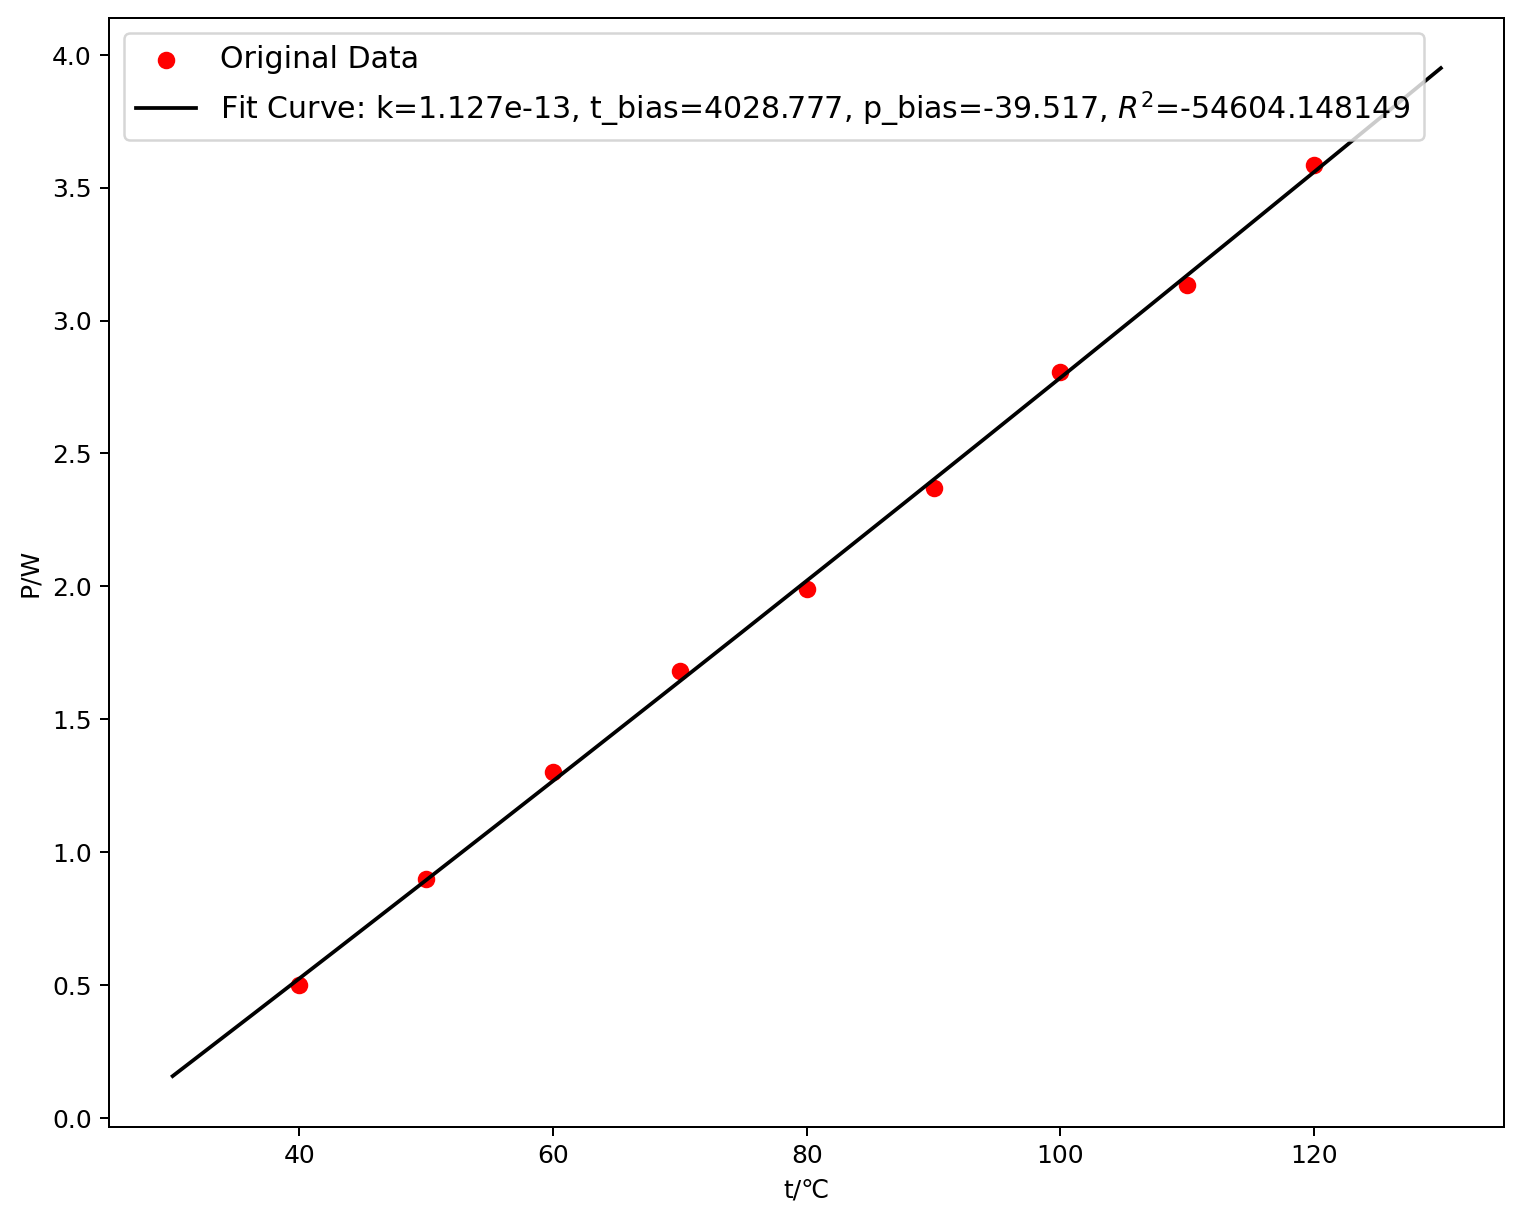

In [26]:
# 读取Excel文件中的数据
df4 = pd.read_excel('data.xlsx', sheet_name='T')

# 提取需要拟合的数据列
# 将x_data和y_data转换为numpy数组
x_data4 = np.array(df4['表面温度'])
y_data4 = np.array(df4['电源功率/W'])

# 定义要拟合的函数模型
def func4(t, k, t_bias, p_bias):
    return k * (t + 273.15 + t_bias)**4 + p_bias

# 使用curve_fit进行拟合
popt4, pcov4 = curve_fit(func4, x_data4, y_data4, maxfev=10000)

# 计算相关系数
residuals4 = y_data4 - func4(x_data4, *popt3)
ss_res4 = np.sum(residuals4**2)
ss_tot4 = np.sum((y_data4 - np.mean(y_data4))**2)
r_squared4 = 1 - (ss_res4 / ss_tot4)

# 绘制拟合结果
x_plot4 = np.linspace(30, 130, num=1000)
plt.figure(figsize=(10, 8), dpi=180) # 图像大小，清晰度
plt.scatter(x_data4, y_data4, label='Original Data', color='r')
plt.plot(x_plot4, func4(x_plot4, *popt4), 'k-', label='Fit Curve: k=%5.3e, t_bias=%5.3f, p_bias=%5.3f, $R^2$=%.6f ' % (*popt4, r_squared4))
plt.xlabel('t/℃')
plt.ylabel('P/W')
plt.legend(fontsize=12) # 标签大小
plt.show()

拟合参数: [3.65096497e+06 3.12173403e+01 5.25010702e+01]
相关系数: 0.9994256051432695


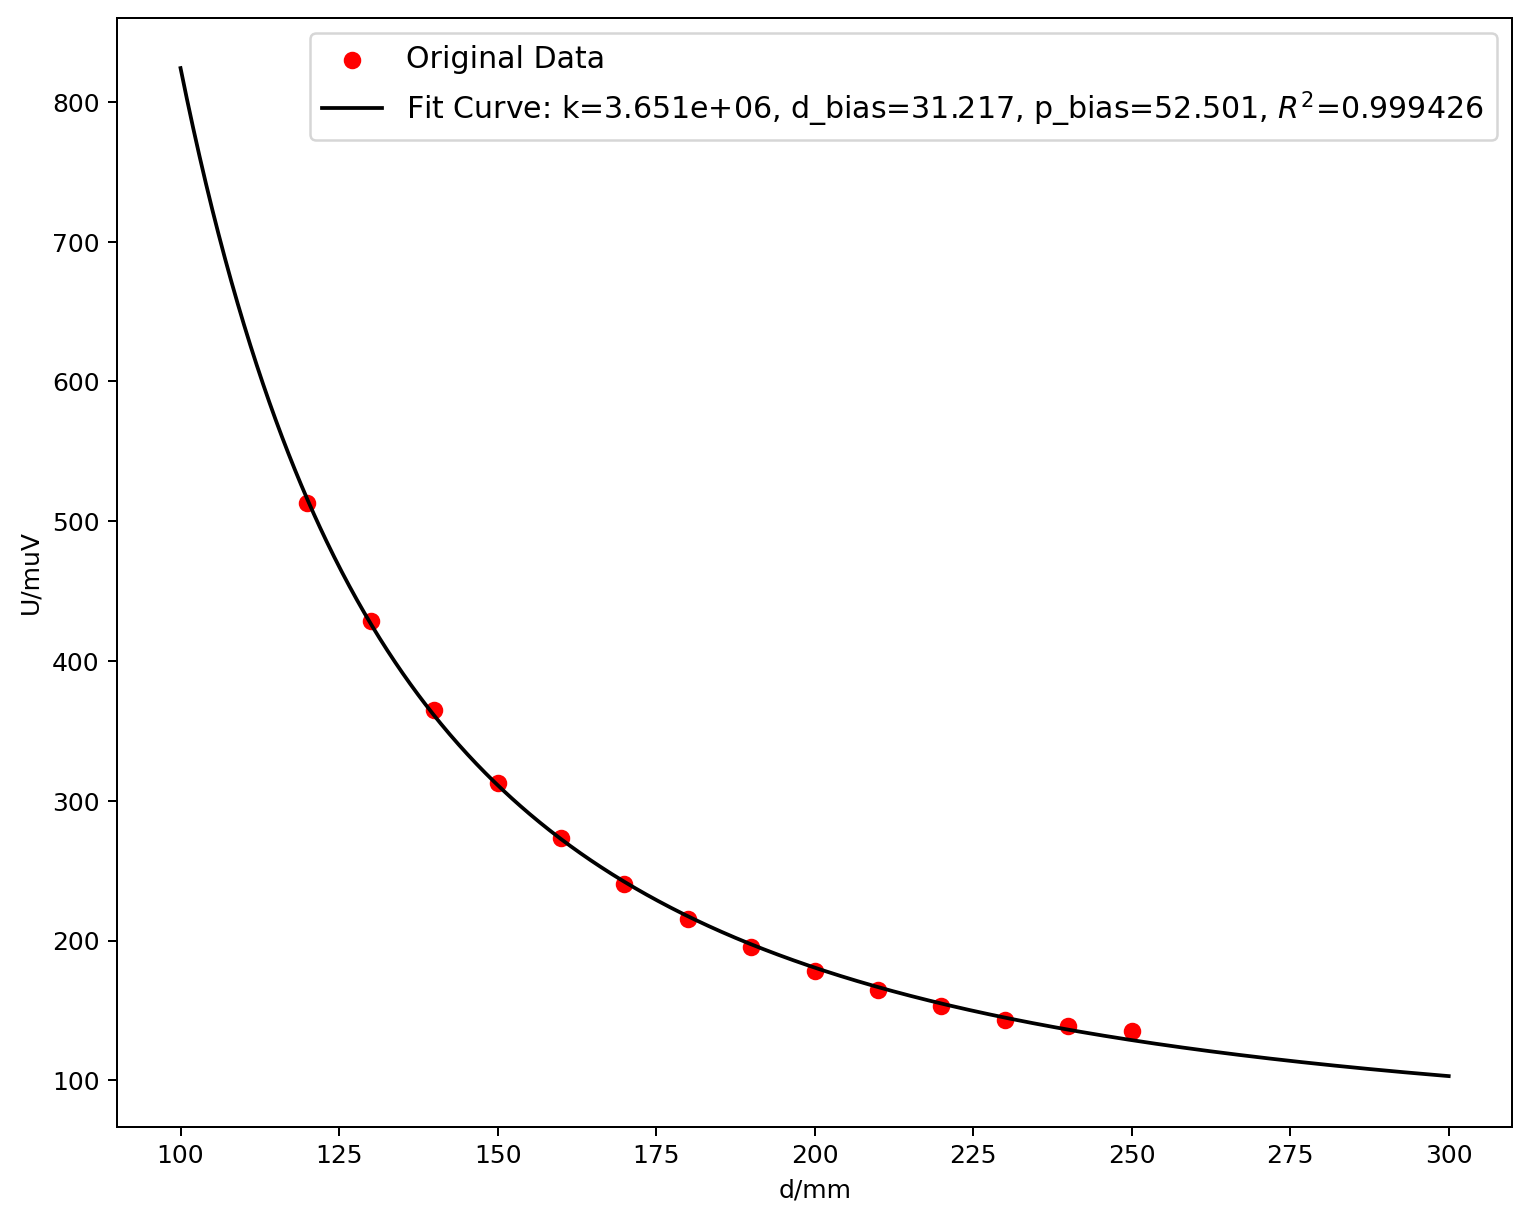

In [16]:
# 读取Excel文件中的数据
df5 = pd.read_excel('data.xlsx', sheet_name='D')

# 提取需要拟合的数据列
# 将x_data和y_data转换为numpy数组
x_data5 = np.array(df5['距离/mm'])
y_data5 = np.array(df5['辐射传感器电压/mV']) 


# 定义要拟合的函数模型
def func5(d, k, d_bias, p_bias):
    return k * (d - d_bias)**(-2) + p_bias


initial_guess5 = [1000, 34.0, 100]
# 使用curve_fit进行拟合
popt5, pcov5 = curve_fit(func5, x_data5, y_data5, p0=initial_guess5)

# 计算相关系数
residuals5 = y_data5 - func5(x_data5, *popt5)
ss_res5 = np.sum(residuals5**2)
ss_tot5 = np.sum((y_data5 - np.mean(y_data5))**2)
r_squared5 = 1 - (ss_res5 / ss_tot5)

# 输出拟合参数
print("拟合参数:", popt5)
print("相关系数:", r_squared5)



# 绘制拟合结果
x_plot5 = np.linspace(100, 300, num=1000)
plt.figure(figsize=(10, 8), dpi=180) # 图像大小，清晰度
plt.scatter(x_data5, y_data5, label='Original Data', color='r')
plt.plot(x_plot5, func5(x_plot5, *popt5), 'k-', label='Fit Curve: k=%5.3e, d_bias=%5.3f, p_bias=%5.3f, $R^2$=%.6f ' % (*popt5, r_squared5))
plt.xlabel('d/mm')
plt.ylabel('U/muV')
plt.legend(fontsize=12) # 标签大小
plt.show()

拟合参数: [751.60118751  47.79789364  79.25154814  76.99905536]
相关系数: 0.9998276427586801


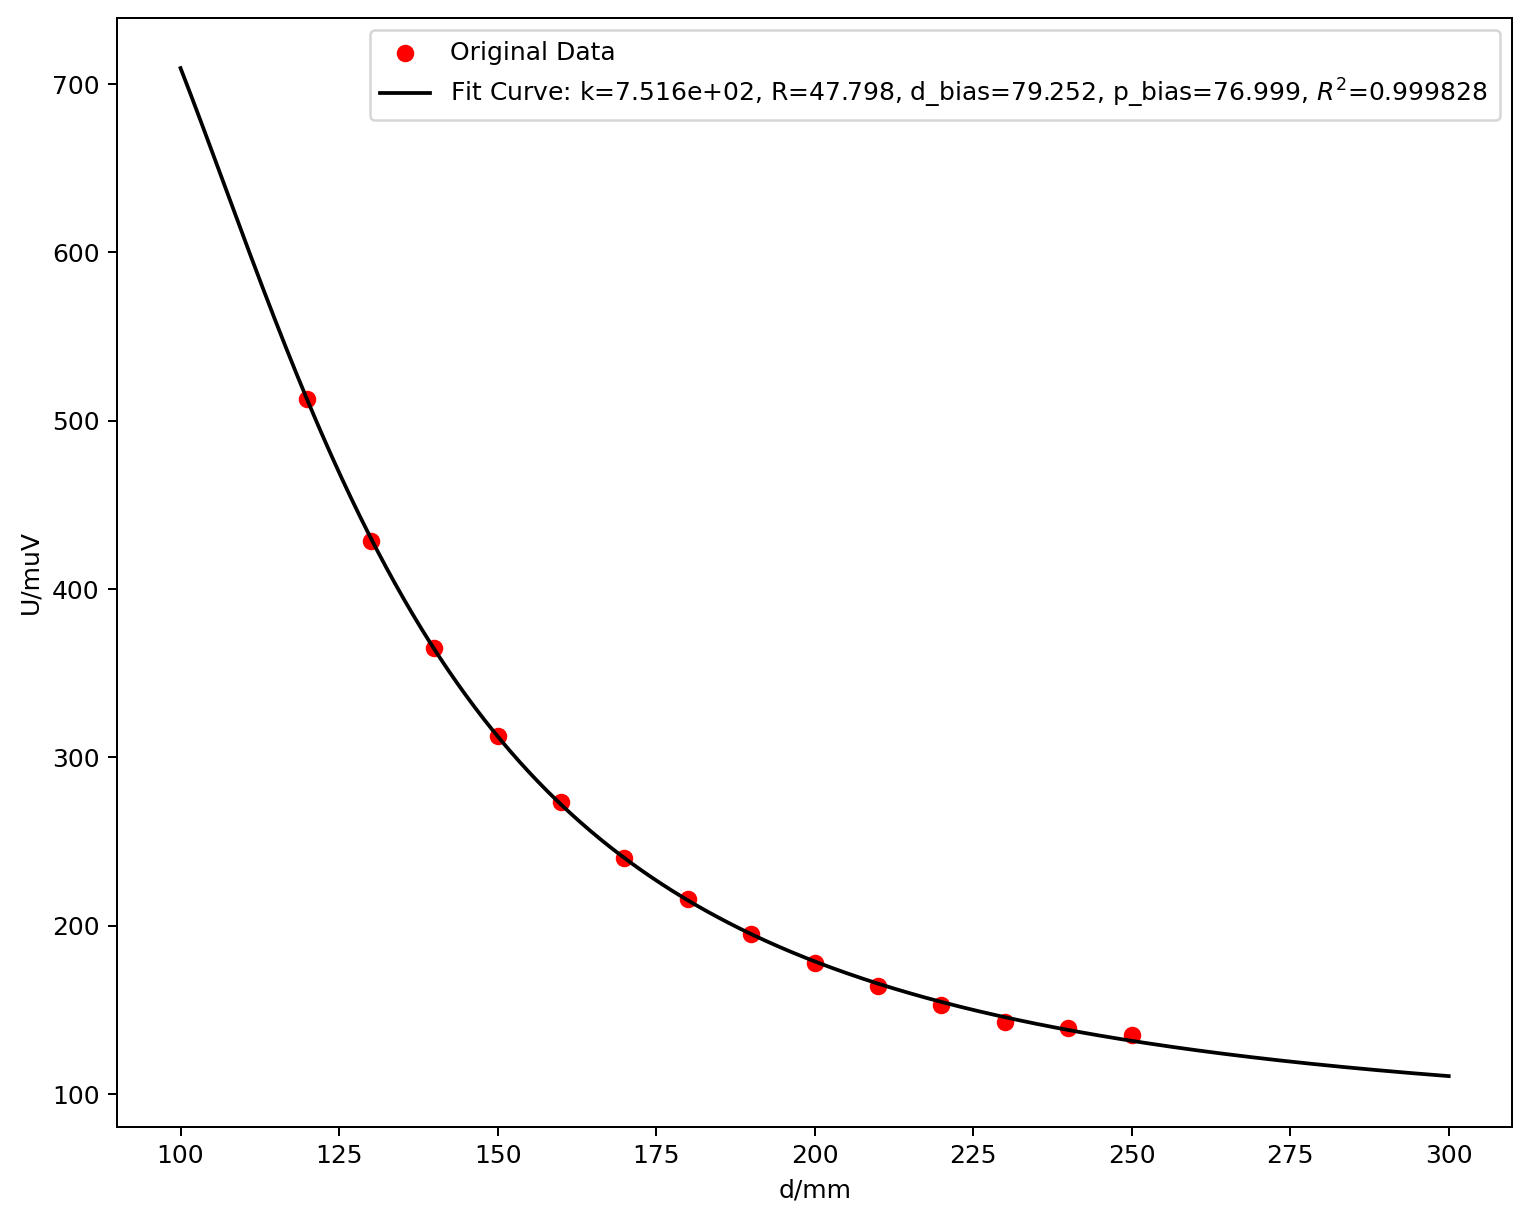

In [9]:
# 定义要拟合的函数模型
def func6(d, k, R, d_bias, p_bias):
    return k * (np.sin(np.arctan(R / (d - d_bias))))**2 + p_bias

initial_guess6 = [10000, 20, 34.0, 50]
# 使用curve_fit进行拟合
popt6, pcov6 = curve_fit(func6, x_data5, y_data5, p0=initial_guess6)

# 计算相关系数
residuals6 = y_data5 - func6(x_data5, *popt6)
ss_res6 = np.sum(residuals6**2)
ss_tot6 = np.sum((y_data5 - np.mean(y_data5))**2)
r_squared6 = 1 - (ss_res6 / ss_tot6)

# 输出拟合参数
print("拟合参数:", popt6)
print("相关系数:", r_squared6)

# 绘制拟合结果
x_plot5 = np.linspace(100, 300, num=1000)
plt.figure(figsize=(10, 8), dpi=180) # 图像大小，清晰度
plt.scatter(x_data5, y_data5, label='Original Data', color='r')
plt.plot(x_plot5, func6(x_plot5, *popt6), 'k-', label='Fit Curve: k=%5.3e, R=%5.3f, d_bias=%5.3f, p_bias=%5.3f, $R^2$=%.6f ' % (*popt6, r_squared6))
plt.xlabel('d/mm')
plt.ylabel('U/muV')
plt.legend(fontsize=10) # 标签大小
plt.show()